# Visualizaciones

In [4]:
## Librerias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import torch
from transformers import BertModel, BertTokenizer
import gensim.downloader as api
from matplotlib.patches import FancyBboxPatch
# Example code structure for testing the analogy
from gensim.models import Word2Vec, KeyedVectors


In [8]:
# Load a pre-trained model
#wv = KeyedVectors.load_word2vec_format("glove-wiki-gigaword-100") #KeyedVectors.load_word2vec_format('path/to/your/model.bin', binary=True)

# Or load a model using the Gensim downloader API
import gensim.downloader as api
model = api.load (glove-wiki-gigaword-100)  #('word2vec-google-news-300')

NameError: name 'glove' is not defined

In [2]:
# Perform the vector operation
result = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(result)  # This should output [('queen', similarity_score)]

MemoryError: Unable to allocate 3.35 GiB for an array with shape (3000000, 300) and data type float32

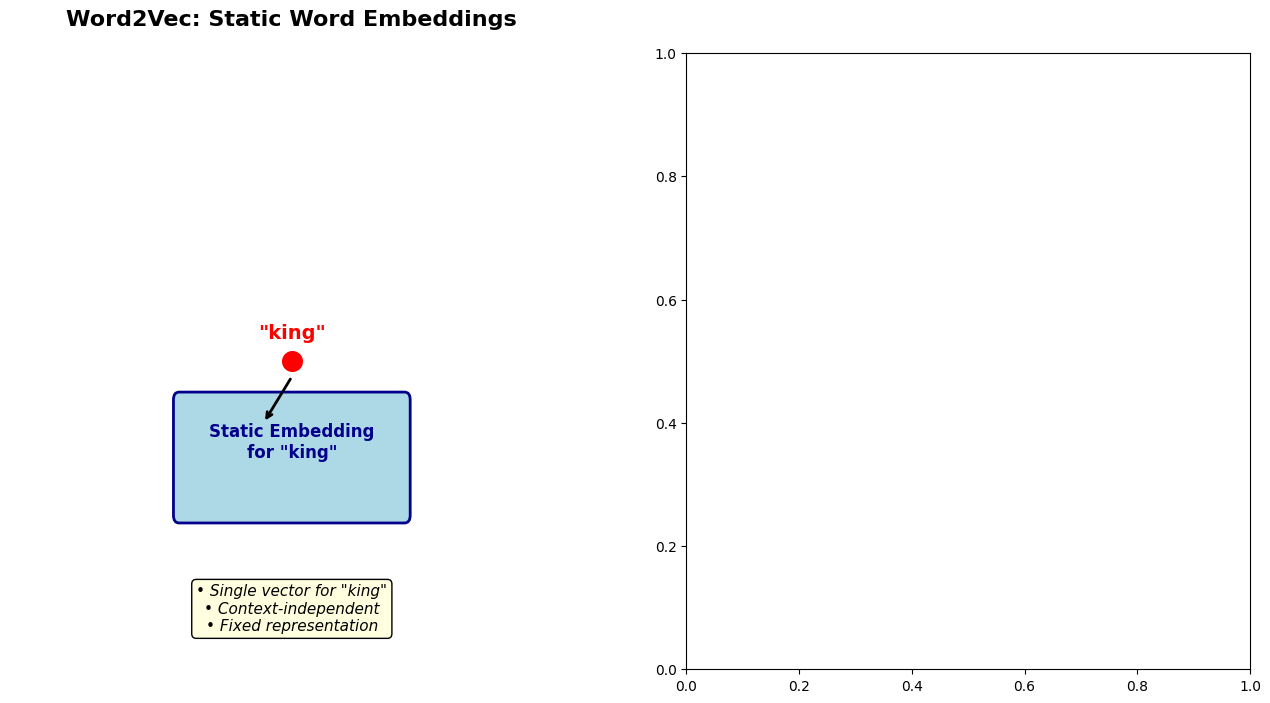

In [2]:
# Configuración de estilo para mejores visualizaciones
plt.style.use('default')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# =============================================================================
# 1. VISUALIZACIÓN WORD2VEC (EMBEDDINGS ESTÁTICOS)
# =============================================================================

ax1.set_title('Word2Vec: Static Word Embeddings', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)

# Punto único para "king" en Word2Vec
king_point = [5, 4]
ax1.scatter(king_point[0], king_point[1], color='red', s=200, zorder=5)
ax1.text(king_point[0], king_point[1] + 0.3, '"king"', fontsize=14, 
         fontweight='bold', ha='center', color='red')

# Caja representando el embedding estático
embedding_box = FancyBboxPatch((3, 2), 4, 1.5, boxstyle="round,pad=0.1",
                              facecolor='lightblue', edgecolor='darkblue', linewidth=2)
ax1.add_patch(embedding_box)
ax1.text(5, 2.75, 'Static Embedding\nfor "king"', fontsize=12, ha='center', 
         fontweight='bold', color='darkblue')

# Flecha conectando la palabra al embedding
ax1.annotate('', xy=(4.5, 3.2), xytext=(5, 3.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='black'))

ax1.text(5, 0.5, '• Single vector for "king"\n• Context-independent\n• Fixed representation', 
         fontsize=11, ha='center', style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

ax1.set_xticks([])
ax1.set_yticks([])
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.spines['left'].set_visible(False)

In [3]:
# =============================================================================
# 2. VISUALIZACIÓN BERT (EMBEDDINGS CONTEXTUALES)
# =============================================================================

ax2.set_title('BERT: Contextual Word Embeddings', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)

# Dos puntos diferentes para "king" en diferentes contextos
king_context1 = [3, 6]
king_context2 = [7, 6]

ax2.scatter(king_context1[0], king_context1[1], color='red', s=200, zorder=5)
ax2.scatter(king_context2[0], king_context2[1], color='red', s=200, zorder=5)

# Texto de las oraciones
ax2.text(3, 6.8, '"The king of Spain"', fontsize=10, ha='center', 
         bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen"))
ax2.text(7, 6.8, '"The lion is\nthe king of the jungle"', fontsize=10, ha='center',
         bbox=dict(boxstyle="round,pad=0.2", facecolor="lightgreen"))

# Dos cajas diferentes para embeddings contextuales
embedding_box1 = FancyBboxPatch((1.5, 2), 3, 1.5, boxstyle="round,pad=0.1",
                               facecolor='lightcoral', edgecolor='darkred', linewidth=2)
embedding_box2 = FancyBboxPatch((5.5, 2), 3, 1.5, boxstyle="round,pad=0.1",
                               facecolor='lightcoral', edgecolor='darkred', linewidth=2)

ax2.add_patch(embedding_box1)
ax2.add_patch(embedding_box2)

ax2.text(3, 2.75, 'Contextual\nEmbedding 1', fontsize=11, ha='center', 
         fontweight='bold', color='darkred')
ax2.text(7, 2.75, 'Contextual\nEmbedding 2', fontsize=11, ha='center', 
         fontweight='bold', color='darkred')

# Flechas conectando los contextos a sus embeddings
ax2.annotate('', xy=(2.5, 3.2), xytext=(3, 5.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='darkred'))
ax2.annotate('', xy=(6.5, 3.2), xytext=(7, 5.8),
            arrowprops=dict(arrowstyle='->', lw=2, color='darkred'))

ax2.text(5, 0.5, '• Different vectors for "king"\n• Context-dependent\n• Dynamic representation', 
         fontsize=11, ha='center', style='italic', bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow"))

ax2.set_xticks([])
ax2.set_yticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['left'].set_visible(False)

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

In [ ]:

# =============================================================================
# 3. DEMOSTRACIÓN PRÁCTICA CON MODELOS REALES (OPCIONAL)
# =============================================================================

print("=" * 70)
print("DEMONSTRATION WITH REAL MODELS")
print("=" * 70)

# Cargar Word2Vec pre-entrenado
print("\n1. Loading Word2Vec model...")
try:
    word2vec_model = api.load('word2vec-google-news-300')
    king_vector_w2v = word2vec_model['king']
    print(f"✓ Word2Vec: Vector for 'king' shape: {king_vector_w2v.shape}")
    print(f"  Single static vector across all contexts")
except:
    print("✗ Word2Vec model not available, but concept remains valid")

# Cargar BERT y demostrar embeddings contextuales
print("\n2. Loading BERT model for contextual embeddings...")
try:
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    model = BertModel.from_pretrained('bert-base-uncased')
    
    # Dos oraciones diferentes con la palabra "king"
    sentences = [
        "The king of Spain gave a speech",
        "The lion is the king of the jungle"
    ]
    
    print(f"✓ BERT model loaded successfully")
    print(f"  Analyzing 2 different contexts for 'king':")
    
    for i, sentence in enumerate(sentences):
        inputs = tokenizer(sentence, return_tensors='pt', padding=True, truncation=True)
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Obtener los embeddings de la última capa
        embeddings = outputs.last_hidden_state
        
        # Encontrar la posición de "king" en los tokens
        tokens = tokenizer.tokenize(sentence)
        king_index = tokens.index('king') if 'king' in tokens else -1
        
        if king_index != -1:
            king_embedding = embeddings[0, king_index + 1, :]  # +1 por el token [CLS]
            print(f"  Context {i+1}: '{sentence}'")
            print(f"    Embedding shape: {king_embedding.shape}")
            print(f"    First 5 values: {king_embedding[:5].numpy()}")
            print()
            
except Exception as e:
    print(f"✗ BERT demonstration failed: {e}")
    print("  But the conceptual difference is clearly shown in the visualization")

print("=" * 70)
print("KEY TAKEAWAYS:")
print("• Word2Vec: One word → One vector (static)")
print("• BERT: One word → Multiple vectors (contextual)")
print("• Context matters for nuanced semantic understanding")
print("=" * 70)

DEMONSTRATION WITH REAL MODELS

1. Loading Word2Vec model...
[=====---------------------------------------------] 10.7% 178.2/1662.8MB downloaded